# CMP461 Pattern Recognition - Midterm Project
## Phase 2: MLP (Multi-Layer Perceptron) Comparative Analysis

**Author:** Efe Yaşar  
**Student ID:** 210408030  

--- 

### Objective / Amaç
In this step, we implement 5 different MLP architectures and train them for 15 epochs each. We will compare their performance using metrics like Accuracy, Loss, and Confusion Matrices. All results will be saved in `results/mlp` for our final report.

Bu adımda, 5 farklı MLP mimarisi uyguluyor ve her birini 15 epok boyunca eğitiyoruz. Performanslarını Doğruluk (Accuracy), Kayıp (Loss) ve Karmaşıklık Matrisi gibi metriklerle karşılaştıracağız. Tüm sonuçlar final raporumuz için `results/mlp` klasörüne kaydedilecektir.

In [5]:
# --- STEP 1: Dependencies and Data Loading ---
# --- ADIM 1: Kütüphaneler ve Veri Yükleme ---

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Directory setup / Dizin kurulumu
RESULTS_DIR = "results/mlp"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Load preprocessed data / Ön işlenmiş verileri yükle
print("📊 Loading data... / Veriler yükleniyor...")
data = np.load("preprocessed_data.npz")
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]

# MLP requires flattening / MLP düzleştirme gerektirir
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

classes = ["Cats", "Dogs", "Snakes"]
input_dim = X_train_flat.shape[1]

print(f"✅ Data ready for MLP experiments. Features: {input_dim}")

📊 Loading data... / Veriler yükleniyor...
✅ Data ready for MLP experiments. Features: 49152


In [6]:
# --- STEP 2: Experiment Factory ---
# --- ADIM 2: Deney Fabrikası ---

def build_mlp(config):
    """
    Creates a custom MLP based on config. / Yapılandırmaya göre özel MLP oluşturur.
    """
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    for units in config['hidden_layers']:
        model.add(layers.Dense(units, activation=config['activation']))
        if config.get('dropout'):
            model.add(layers.Dropout(config['dropout']))
            
    model.add(layers.Dense(3, activation='softmax'))
    
    opt = getattr(optimizers, config['optimizer'])(learning_rate=0.001)
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 5 Different configurations for our study / Çalışmamız için 5 farklı yapılandırma
experiments = [
    {"name": "MLP_V1_Shallow", "hidden_layers": [128], "activation": "relu", "optimizer": "Adam"},
    {"name": "MLP_V2_Deep", "hidden_layers": [256, 128, 64], "activation": "relu", "optimizer": "Adam"},
    {"name": "MLP_V3_Tanh_RMS", "hidden_layers": [128, 128], "activation": "tanh", "optimizer": "RMSprop"},
    {"name": "MLP_V4_Wide_SGD", "hidden_layers": [512], "activation": "sigmoid", "optimizer": "SGD"},
    {"name": "MLP_V5_Optimized", "hidden_layers": [256, 128], "activation": "relu", "optimizer": "Adam", "dropout": 0.2}
]


🚀 Starting: MLP_V1_Shallow...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3630 - loss: 10.3458 - val_accuracy: 0.3711 - val_loss: 6.5118
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3977 - loss: 6.7731 - val_accuracy: 0.4289 - val_loss: 4.8113
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4736 - loss: 4.1241 - val_accuracy: 0.4178 - val_loss: 4.2656
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4532 - loss: 4.0538 - val_accuracy: 0.4156 - val_loss: 4.1692
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4627 - loss: 3.8757 - val_accuracy: 0.4289 - val_loss: 3.4267
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5266 - loss: 2.0809 - val_accuracy: 0.3667 - val_loss: 5.5807
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5013 - loss: 3.4103 - val_accuracy: 0.4178 - val_loss: 2.4211
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5160 - loss: 2

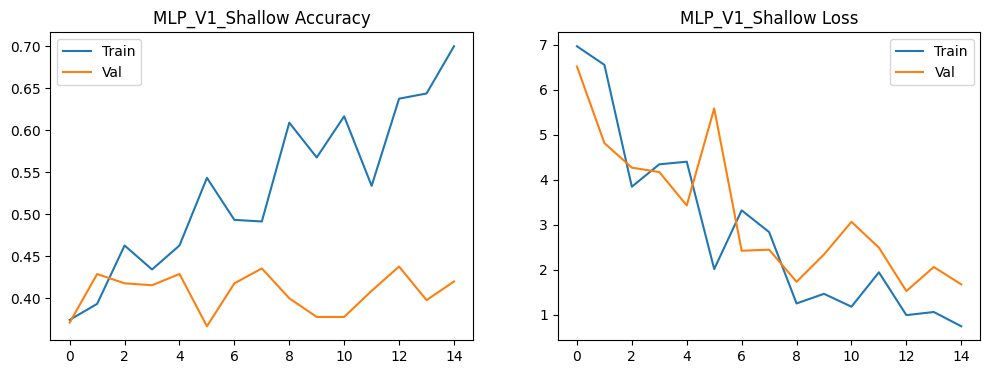

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


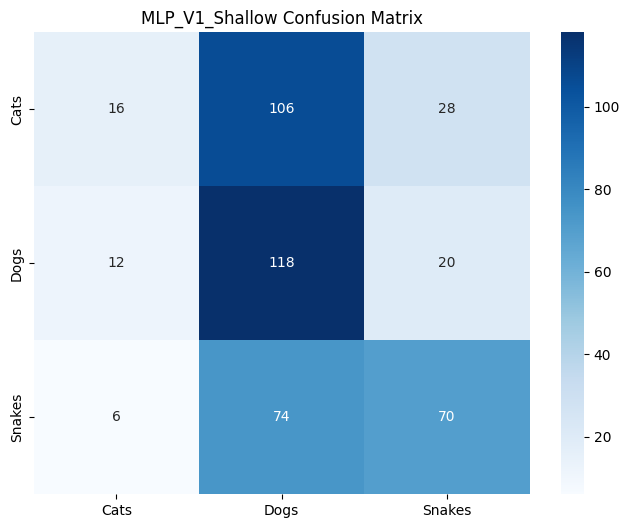


🚀 Starting: MLP_V2_Deep...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3293 - loss: 9.3491 - val_accuracy: 0.4267 - val_loss: 1.2879
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4573 - loss: 1.3647 - val_accuracy: 0.4378 - val_loss: 1.1134
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4532 - loss: 1.2436 - val_accuracy: 0.3533 - val_loss: 1.6635
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4596 - loss: 1.2036 - val_accuracy: 0.4556 - val_loss: 1.0766
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4836 - loss: 1.1085 - val_accuracy: 0.4178 - val_loss: 1.1819
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4777 - loss: 1.1340 - val_accuracy: 0.4889 - val_loss: 0.9954
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5513 - loss: 0.9348 - val_accuracy: 0.4600 - val_loss: 1.0285
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5280 - loss: 0.974

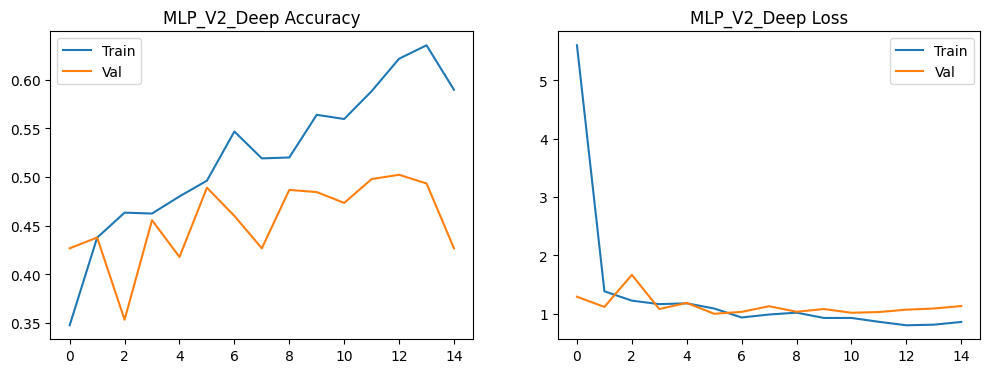

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


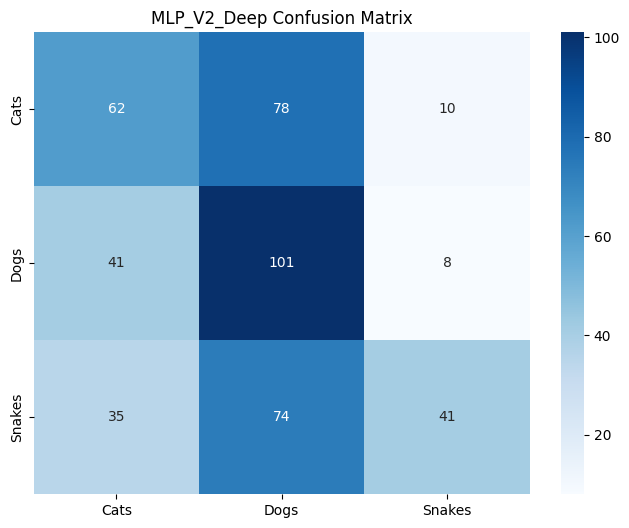


🚀 Starting: MLP_V3_Tanh_RMS...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3319 - loss: 1.2972 - val_accuracy: 0.3356 - val_loss: 1.1020
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3348 - loss: 1.1383 - val_accuracy: 0.3333 - val_loss: 1.1747
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3226 - loss: 1.1252 - val_accuracy: 0.3378 - val_loss: 1.0994
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3348 - loss: 1.1105 - val_accuracy: 0.3400 - val_loss: 1.0971
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3226 - loss: 1.1092 - val_accuracy: 0.3333 - val_loss: 1.1111
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3276 - loss: 1.1078 - val_accuracy: 0.3378 - val_loss: 1.0973
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3584 - loss: 1.1021 - val_accuracy: 0.3356 - val_loss: 1.1017
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3567 - loss: 1

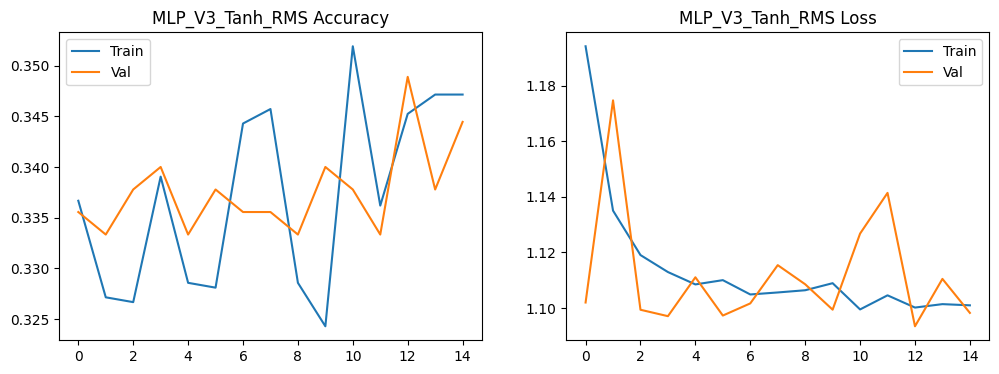

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


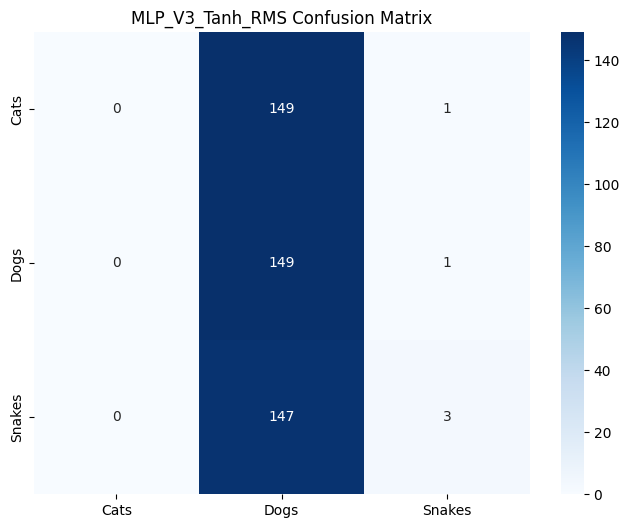


🚀 Starting: MLP_V4_Wide_SGD...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3697 - loss: 1.1048 - val_accuracy: 0.4111 - val_loss: 1.0959
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.3981 - loss: 1.0917 - val_accuracy: 0.4311 - val_loss: 1.0785
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4451 - loss: 1.0677 - val_accuracy: 0.3844 - val_loss: 1.0749
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4417 - loss: 1.0596 - val_accuracy: 0.4778 - val_loss: 1.0499
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4827 - loss: 1.0438 - val_accuracy: 0.4400 - val_loss: 1.0534
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4699 - loss: 1.0313 - val_accuracy: 0.4022 - val_loss: 1.0612
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4912 - loss: 1.0197 - val_accuracy: 0.4533 - val_loss: 1.0451
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4894 - loss: 1

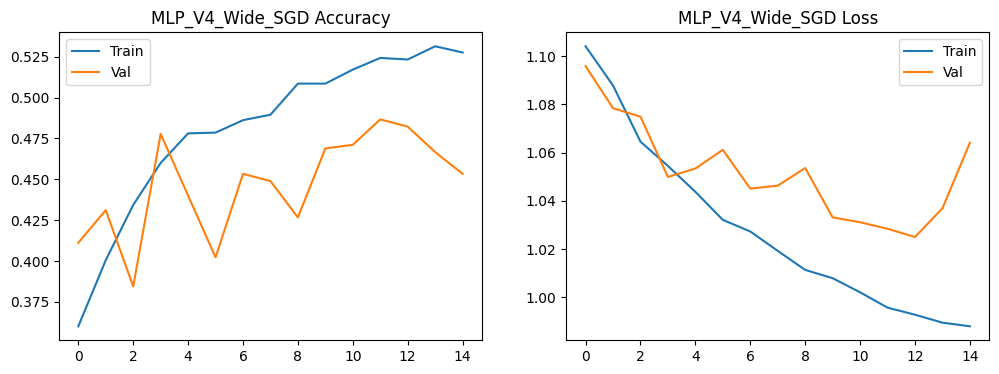

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


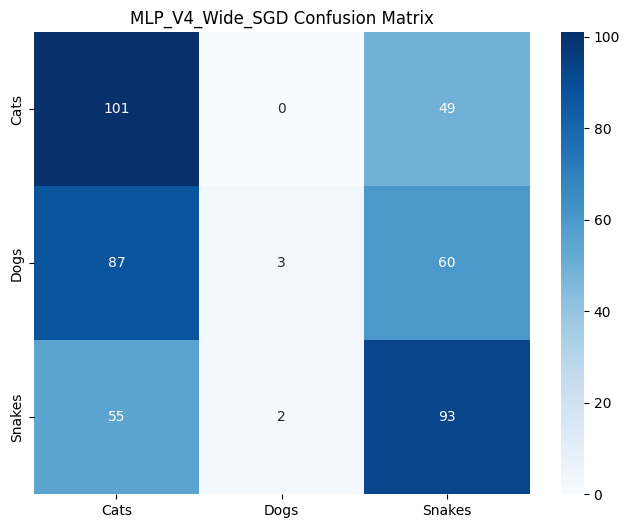


🚀 Starting: MLP_V5_Optimized...
Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3305 - loss: 9.0061 - val_accuracy: 0.5044 - val_loss: 1.0398
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3788 - loss: 1.4087 - val_accuracy: 0.4000 - val_loss: 1.0503
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4129 - loss: 1.0768 - val_accuracy: 0.4200 - val_loss: 1.0521
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3755 - loss: 1.0650 - val_accuracy: 0.4600 - val_loss: 1.0274
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3692 - loss: 1.0893 - val_accuracy: 0.3756 - val_loss: 1.0919
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3080 - loss: 1.0992 - val_accuracy: 0.3333 - val_loss: 1.0932
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3362 - loss: 1.0959 - val_accuracy: 0.3333 - val_loss: 1.0917
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3561 - loss: 

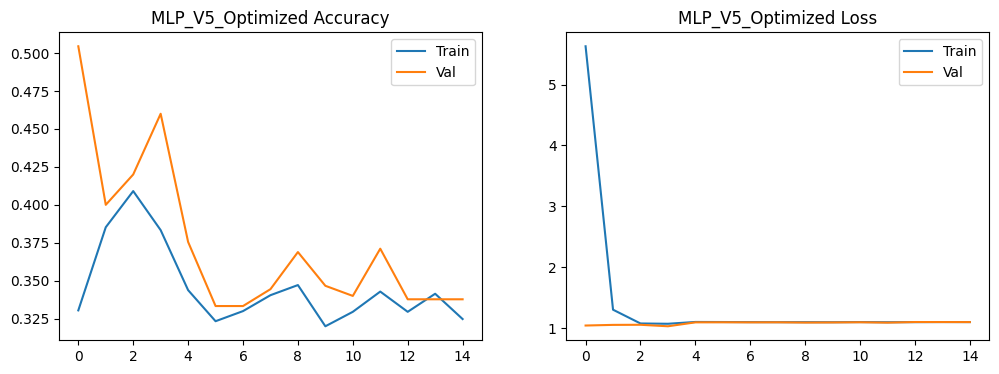

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


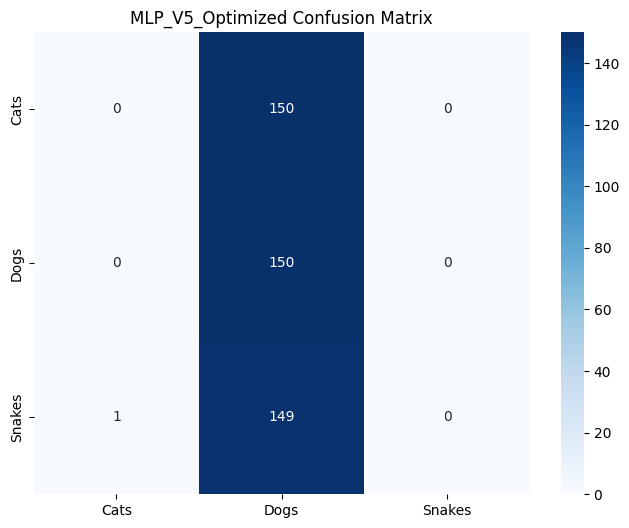

✅ All MLP experiments finished! / Tüm MLP deneyleri bitti!


In [7]:
# --- STEP 3: Running Experiments (15 Epochs) ---
# --- ADIM 3: Deneyleri Çalıştırma (15 Epok) ---

summary_stats = []

for exp in experiments:
    print(f"\n🚀 Starting: {exp['name']}...")
    model = build_mlp(exp)
    
    # We train for 15 epochs as requested. / İstenildiği gibi 15 epok eğitiyoruz.
    history = model.fit(
        X_train_flat, y_train,
        validation_data=(X_val_flat, y_val),
        epochs=15,
        batch_size=32,
        verbose=1
    )
    
    # Evaluation / Değerlendirme
    test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)
    summary_stats.append({**exp, "Accuracy": test_acc, "Loss": test_loss})
    
    # Plotting Curves / Eğitim Eğrilerini Çizdirme
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f"{exp['name']} Accuracy")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f"{exp['name']} Loss")
    plt.legend()
    
    plt.savefig(f"{RESULTS_DIR}/{exp['name']}_history.png")
    plt.show()
    
    # Confusion Matrix / Karmaşıklık Matrisi
    y_pred = np.argmax(model.predict(X_test_flat), axis=1)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.title(f"{exp['name']} Confusion Matrix")
    plt.savefig(f"{RESULTS_DIR}/{exp['name']}_cm.png")
    plt.show()
    
    model.save(f"models/Efe_Yasar_{exp['name']}.keras")

print("✅ All MLP experiments finished! / Tüm MLP deneyleri bitti!")

In [8]:
# --- STEP 4: Final Comparison --- 
# --- ADIM 4: Final Karşılaştırma ---

df_results = pd.DataFrame(summary_stats)
df_results.to_csv(f"{RESULTS_DIR}/mlp_results.csv", index=False)

print("📝 Comparison Table: / Karşılaştırma Tablosu:")
print(df_results[['name', 'Accuracy', 'Loss', 'activation', 'optimizer']])

📝 Comparison Table: / Karşılaştırma Tablosu:
               name  Accuracy      Loss activation optimizer
0    MLP_V1_Shallow  0.453333  1.612790       relu      Adam
1       MLP_V2_Deep  0.453333  1.093433       relu      Adam
2   MLP_V3_Tanh_RMS  0.337778  1.102451       tanh   RMSprop
3   MLP_V4_Wide_SGD  0.437778  1.069470    sigmoid       SGD
4  MLP_V5_Optimized  0.333333  1.098721       relu      Adam
